In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns 

In [2]:
athlete = pd.read_csv("athlete_events.csv")
region = pd.read_csv("noc_regions.csv")

In [8]:
athlete.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN
271115,135571,Tomasz Ireneusz ya,M,34.0,185.0,96.0,Poland,POL,2002 Winter,2002,Winter,Salt Lake City,Bobsleigh,Bobsleigh Men's Four,NaN


In [10]:
athlete.shape

(271116, 15)

In [8]:
# Excluding Winter Season

athlete = athlete[athlete['Season']=='Summer'] 

In [13]:
athlete.shape

(222552, 15)

In [14]:
# Region dataframe

region.tail()

,NOC,region,notes
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN
229,ZIM,Zimbabwe,NaN


In [4]:
# Merging two datasets

athlete = athlete.merge(region, on='NOC', how='left')

In [8]:
athlete.sample(4)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
221862,135160,Boris Zlokovi,M,29.0,197.0,100.0,Montenegro,MNE,2012 Summer,2012,Summer,London,Water Polo,Water Polo Men's Water Polo,NaN,Montenegro,NaN
50631,30867,Mehmet Dursun,M,48.0,175.0,80.0,Turkey,TUR,1976 Summer,1976,Summer,Montreal,Shooting,"Shooting Mixed Small-Bore Rifle, Prone, 50 metres",NaN,Turkey,NaN
92560,56784,Fujio Kakuta,M,25.0,NaN,NaN,Japan,JPN,1936 Summer,1936,Summer,Berlin,Gymnastics,Gymnastics Men's Rings,NaN,Japan,NaN
200022,122031,Santiago Trompeta Rodrguez,M,19.0,160.0,65.0,Cuba,CUB,1972 Summer,1972,Summer,Munich,Shooting,"Shooting Mixed Free Pistol, 50 metres",NaN,Cuba,NaN


In [6]:
# Total number of countries participated

athlete['region'].unique()

array(['China', 'Denmark', 'Netherlands', 'Finland', 'Norway', 'Romania',
       'Estonia', 'France', 'Morocco', 'Spain', 'Egypt', 'Iran',
       'Bulgaria', 'Italy', 'Chad', 'Azerbaijan', 'Sudan', 'Russia',
       'Argentina', 'Cuba', 'Belarus', 'Greece', 'Cameroon', 'Turkey',
       'Chile', 'Mexico', 'USA', 'Nicaragua', 'Hungary', 'Nigeria',
       'Algeria', 'Kuwait', 'Bahrain', 'Pakistan', 'Iraq', 'Syria',
       'Lebanon', 'Qatar', 'Malaysia', 'Germany', 'Canada', 'Ireland',
       'Australia', 'South Africa', 'Eritrea', 'Tanzania', 'Jordan',
       'Tunisia', 'Libya', 'Belgium', 'Djibouti', 'Palestine', 'Comoros',
       'Kazakhstan', 'Brunei', 'India', 'Saudi Arabia', 'Maldives',
       'Ethiopia', 'United Arab Emirates', 'Yemen', 'Indonesia',
       'Philippines', nan, 'Uzbekistan', 'Kyrgyzstan', 'Tajikistan',
       'Japan', 'Republic of Congo', 'Switzerland', 'Brazil', 'Monaco',
       'Israel', 'Uruguay', 'Sweden', 'Sri Lanka', 'Armenia',
       'Ivory Coast', 'Kenya', 'Ben

In [6]:
# Missing Values 

athlete.isna().sum()

ID             0
Name           0
Sex            0
Age         9189
Height     51857
Weight     53854
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     188464
region       370
notes     218151
dtype: int64

## Duplicate rows

In [7]:
# Duplicate values

athlete.duplicated().sum()

np.int64(1385)

In [9]:
# Removing duplicate rows 

athlete.drop_duplicates(inplace=True)

In [7]:
# Checking duplicate values

athlete.duplicated().sum()

np.int64(0)

## One Hot Encoding

#### Medal Column

In [10]:
athlete['Medal'].value_counts()

Medal
Gold      11456
Bronze    11409
Silver    11212
Name: count, dtype: int64

In [10]:
athlete = pd.concat([athlete, pd.get_dummies(athlete['Medal'], dtype='int')], axis=1)

In [6]:
athlete.shape

(269731, 20)

## Grouping data by NOC

In [13]:
athlete.groupby(by='NOC').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold',ascending=False).reset_index()

,NOC,Gold,Silver,Bronze
0,USA,2472,1333,1197
1,URS,832,635,596
2,GBR,635,729,620
3,GER,592,538,649
4,ITA,518,474,454
...,...,...,...,...
225,WIF,0,0,5
226,YEM,0,0,0
227,YAR,0,0,0
228,YMD,0,0,0


### Conclusion:

##### The above analysis shows the total number of Gold, Silver and Bronze medal entries for each NOC. However, the results cannot be considered the actual number of olympic medals won by each country. This is because the dataset contains one row for each athlete-even, so medals won in team events are repeated for every number of the team. 

- For example: the USA's 2472 Gold entries do not represent 2472 actual Gold Medals.

##### Therefore, the data needs to be further processed to remove duplicate medals entries from team events before calculating the actual medal count of each NOC



## Remove duplicate medal entries

In [11]:
medal_tally = athlete.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])

In [12]:
medal_tally = medal_tally.groupby(by='region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold',ascending=False).reset_index()

In [13]:
# Adding total column in medal_tally dataframe 

medal_tally['Total'] = medal_tally['Gold'] + medal_tally['Silver'] + medal_tally['Bronze']

In [15]:
medal_tally.sample(5)

,region,Gold,Silver,Bronze,Total
83,Panama,1,0,2,3
118,Djibouti,0,0,1,1
39,North Korea,16,15,23,54
190,Philippines,0,3,7,10
29,Serbia,31,39,37,107


## Years in which olympics was played

In [12]:
years = athlete['Year'].unique().tolist()

In [13]:
years.sort()

In [14]:
years.insert(0, 'overall')

In [19]:
years

['overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

## Countries

In [15]:
# Dropping NaN values and converting to list

country = np.unique(athlete['region'].dropna().values).tolist()

In [16]:
# sort countries

country.sort()

In [17]:
country.insert(0, 'overall')

In [23]:
country

['overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

## Function for year and country

In [14]:
# Function that will give output depending on the input 

def fetch_medal_tally(year, country):
    medal_df = athlete.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
    flag = 0
    if year == 'overall' and country == 'overall':
        temp_df = medal_df
    if year == 'overall' and country != 'overall':
        flag = 1
        temp_df = medal_df[medal_df['region'] == country]
    if year != 'overall' and country == 'overall':
        temp_df = medal_df[medal_df['Year'] == int(year)]
    if year != 'overall' and country != 'overall':
        temp_df = medal_df[(medal_df['Year'] == int(year)) & (medal_df['region'] == country)]

    if flag == 1:
         x = temp_df.groupby(by='Year').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Year',ascending=True).reset_index()
    else:
         x = temp_df.groupby(by='region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold',ascending=False).reset_index()

    x['Total'] = x['Gold'] + x['Silver'] + x['Bronze']

    print(x)
        
        
        


In [25]:
fetch_medal_tally(year='1900', country='India')

  region  Gold  Silver  Bronze  Total
0  India     0       2       0      2


In [15]:
medal_df = athlete.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])

In [29]:
medal_df[medal_df['region'] == 'France']

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
48,34,Jamale (Djamel-) Aarrass (Ahrass-),M,30.0,187.0,76.0,France,FRA,2012 Summer,2012,Summer,London,Athletics,"Athletics Men's 1,500 metres",NaN,France,NaN,0,0,0
83,52,Patrick Abada,M,22.0,189.0,80.0,France,FRA,1976 Summer,1976,Summer,Montreal,Athletics,Athletics Men's Pole Vault,NaN,France,NaN,0,0,0
87,56,Ren Abadie,M,21.0,NaN,NaN,France,FRA,1956 Summer,1956,Summer,Melbourne,Cycling,"Cycling Men's Road Race, Individual",NaN,France,NaN,0,0,0
88,56,Ren Abadie,M,21.0,NaN,NaN,France,FRA,1956 Summer,1956,Summer,Melbourne,Cycling,"Cycling Men's Road Race, Team",Gold,France,NaN,0,1,0
111,73,Luc Abalo,M,23.0,182.0,86.0,France,FRA,2008 Summer,2008,Summer,Beijing,Handball,Handball Men's Handball,Gold,France,NaN,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221904,135188,Andr Georges Zoete,M,25.0,156.0,52.0,France,FRA,1956 Summer,1956,Summer,Melbourne,Wrestling,"Wrestling Men's Flyweight, Freestyle",NaN,France,NaN,0,0,0
221905,135188,Andr Georges Zoete,M,28.0,156.0,52.0,France,FRA,1960 Summer,1960,Summer,Roma,Wrestling,"Wrestling Men's Flyweight, Freestyle",NaN,France,NaN,0,0,0
221906,135188,Andr Georges Zoete,M,33.0,156.0,52.0,France,FRA,1964 Summer,1964,Summer,Tokyo,Wrestling,"Wrestling Men's Flyweight, Freestyle",NaN,France,NaN,0,0,0
222079,135278,Vincent Zouaoui-Dandrieux,M,31.0,188.0,72.0,France,FRA,2012 Summer,2012,Summer,London,Athletics,"Athletics Men's 3,000 metres Steeplechase",NaN,France,NaN,0,0,0


In [30]:
athlete.shape

(221167, 20)

## 2. Overall Analysis

- No of editions
- No of cities
- No of events/sports
- No of athletes
- Participating nations 

### a. Year

In [42]:
athlete['Year'].unique().shape[0]-1 

28

### b. Cities

In [47]:
athlete['City'].unique()

array(['Barcelona', 'London', 'Antwerpen', 'Paris', 'Los Angeles',
       'Helsinki', 'Sydney', 'Atlanta', 'Stockholm', 'Beijing',
       'Rio de Janeiro', 'Athina', 'Mexico City', 'Munich', 'Seoul',
       'Berlin', 'Melbourne', 'Roma', 'Amsterdam', 'Montreal', 'Moskva',
       'Tokyo', 'St. Louis'], dtype=object)

### c. Sport

In [50]:
athlete['Sport'].unique()

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

### d. Events

In [51]:
athlete['Event'].unique().shape

(651,)

### e. Athletes

In [53]:
athlete['Name'].unique().shape

(116122,)

### f. Particpating Nations

In [55]:
athlete['region'].unique().shape

(206,)

## Plotting Graphs

### 1. Participating nations over time 

In [16]:
nations_over_time = athlete.drop_duplicates(['Year', 'region'])['Year'].value_counts().reset_index().sort_values('Year')

In [32]:
nations_over_time

,Year,count
28,1896,12
22,1900,31
27,1904,14
26,1906,20
25,1908,22
23,1912,29
24,1920,29
21,1924,45
20,1928,46
19,1932,47


In [17]:
import plotly.express as px 

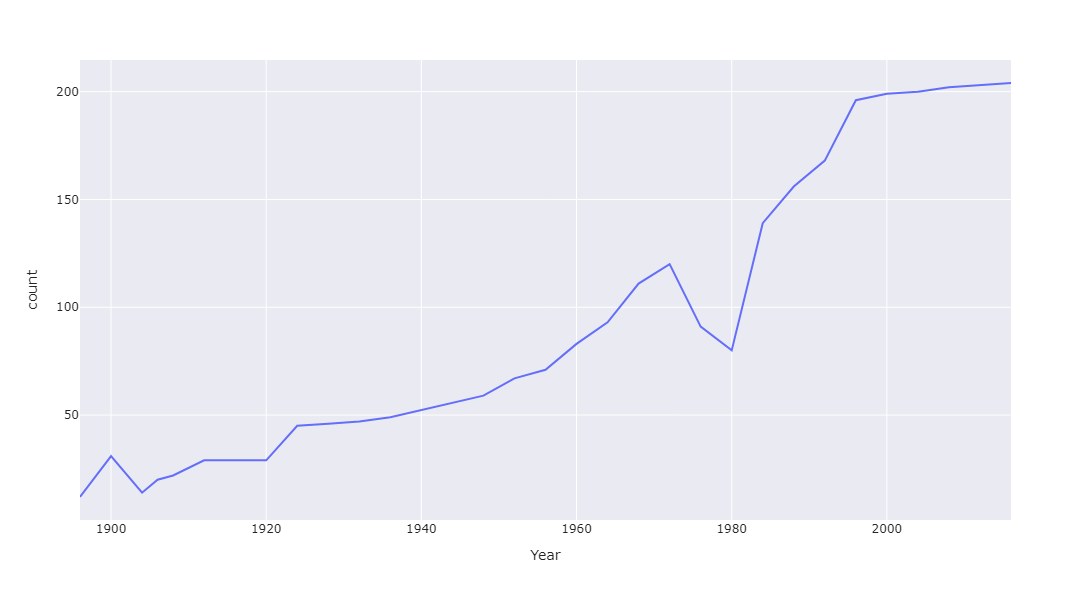

In [22]:
fig = px.line(nations_over_time, x='Year', y='count')

fig.update_layout(width=1000, height=600, template='seaborn')

fig.show()

### 2. Number of Events over the years

In [31]:
athlete.drop_duplicates(['Year', 'Event'])['Year'].value_counts().reset_index().sort_values('Year')

,Year,count
28,1896,43
26,1900,90
25,1904,95
27,1906,74
23,1908,109
24,1912,107
14,1920,158
20,1924,131
22,1928,122
21,1932,131


## Plotting Heatmap

### Number of Events in each Sport over the years

In [23]:
x = athlete.drop_duplicates(['Year', 'Sport', 'Event'])

In [91]:
x.pivot_table(index='Sport', columns='Year', values='Event', aggfunc='count').fillna(0).astype(int)

Year,1896,1900,1904,1906,1908,1912,1920,1924,1928,1932,...,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016
Sport,,,,,,,,,,,,,,,,,,,,,
Aeronautics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alpinism,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Archery,0,8,6,0,3,0,10,0,0,0,...,2,2,4,4,4,4,4,4,4,4
Art Competitions,0,0,0,0,0,5,5,5,13,13,...,0,0,0,0,0,0,0,0,0,0
Athletics,12,23,24,21,26,30,29,27,27,29,...,38,41,42,43,44,46,46,47,47,47
Badminton,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,5,5,5,5,5,5
Baseball,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,0,0
Basketball,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
Basque Pelota,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Year', ylabel='Sport'>

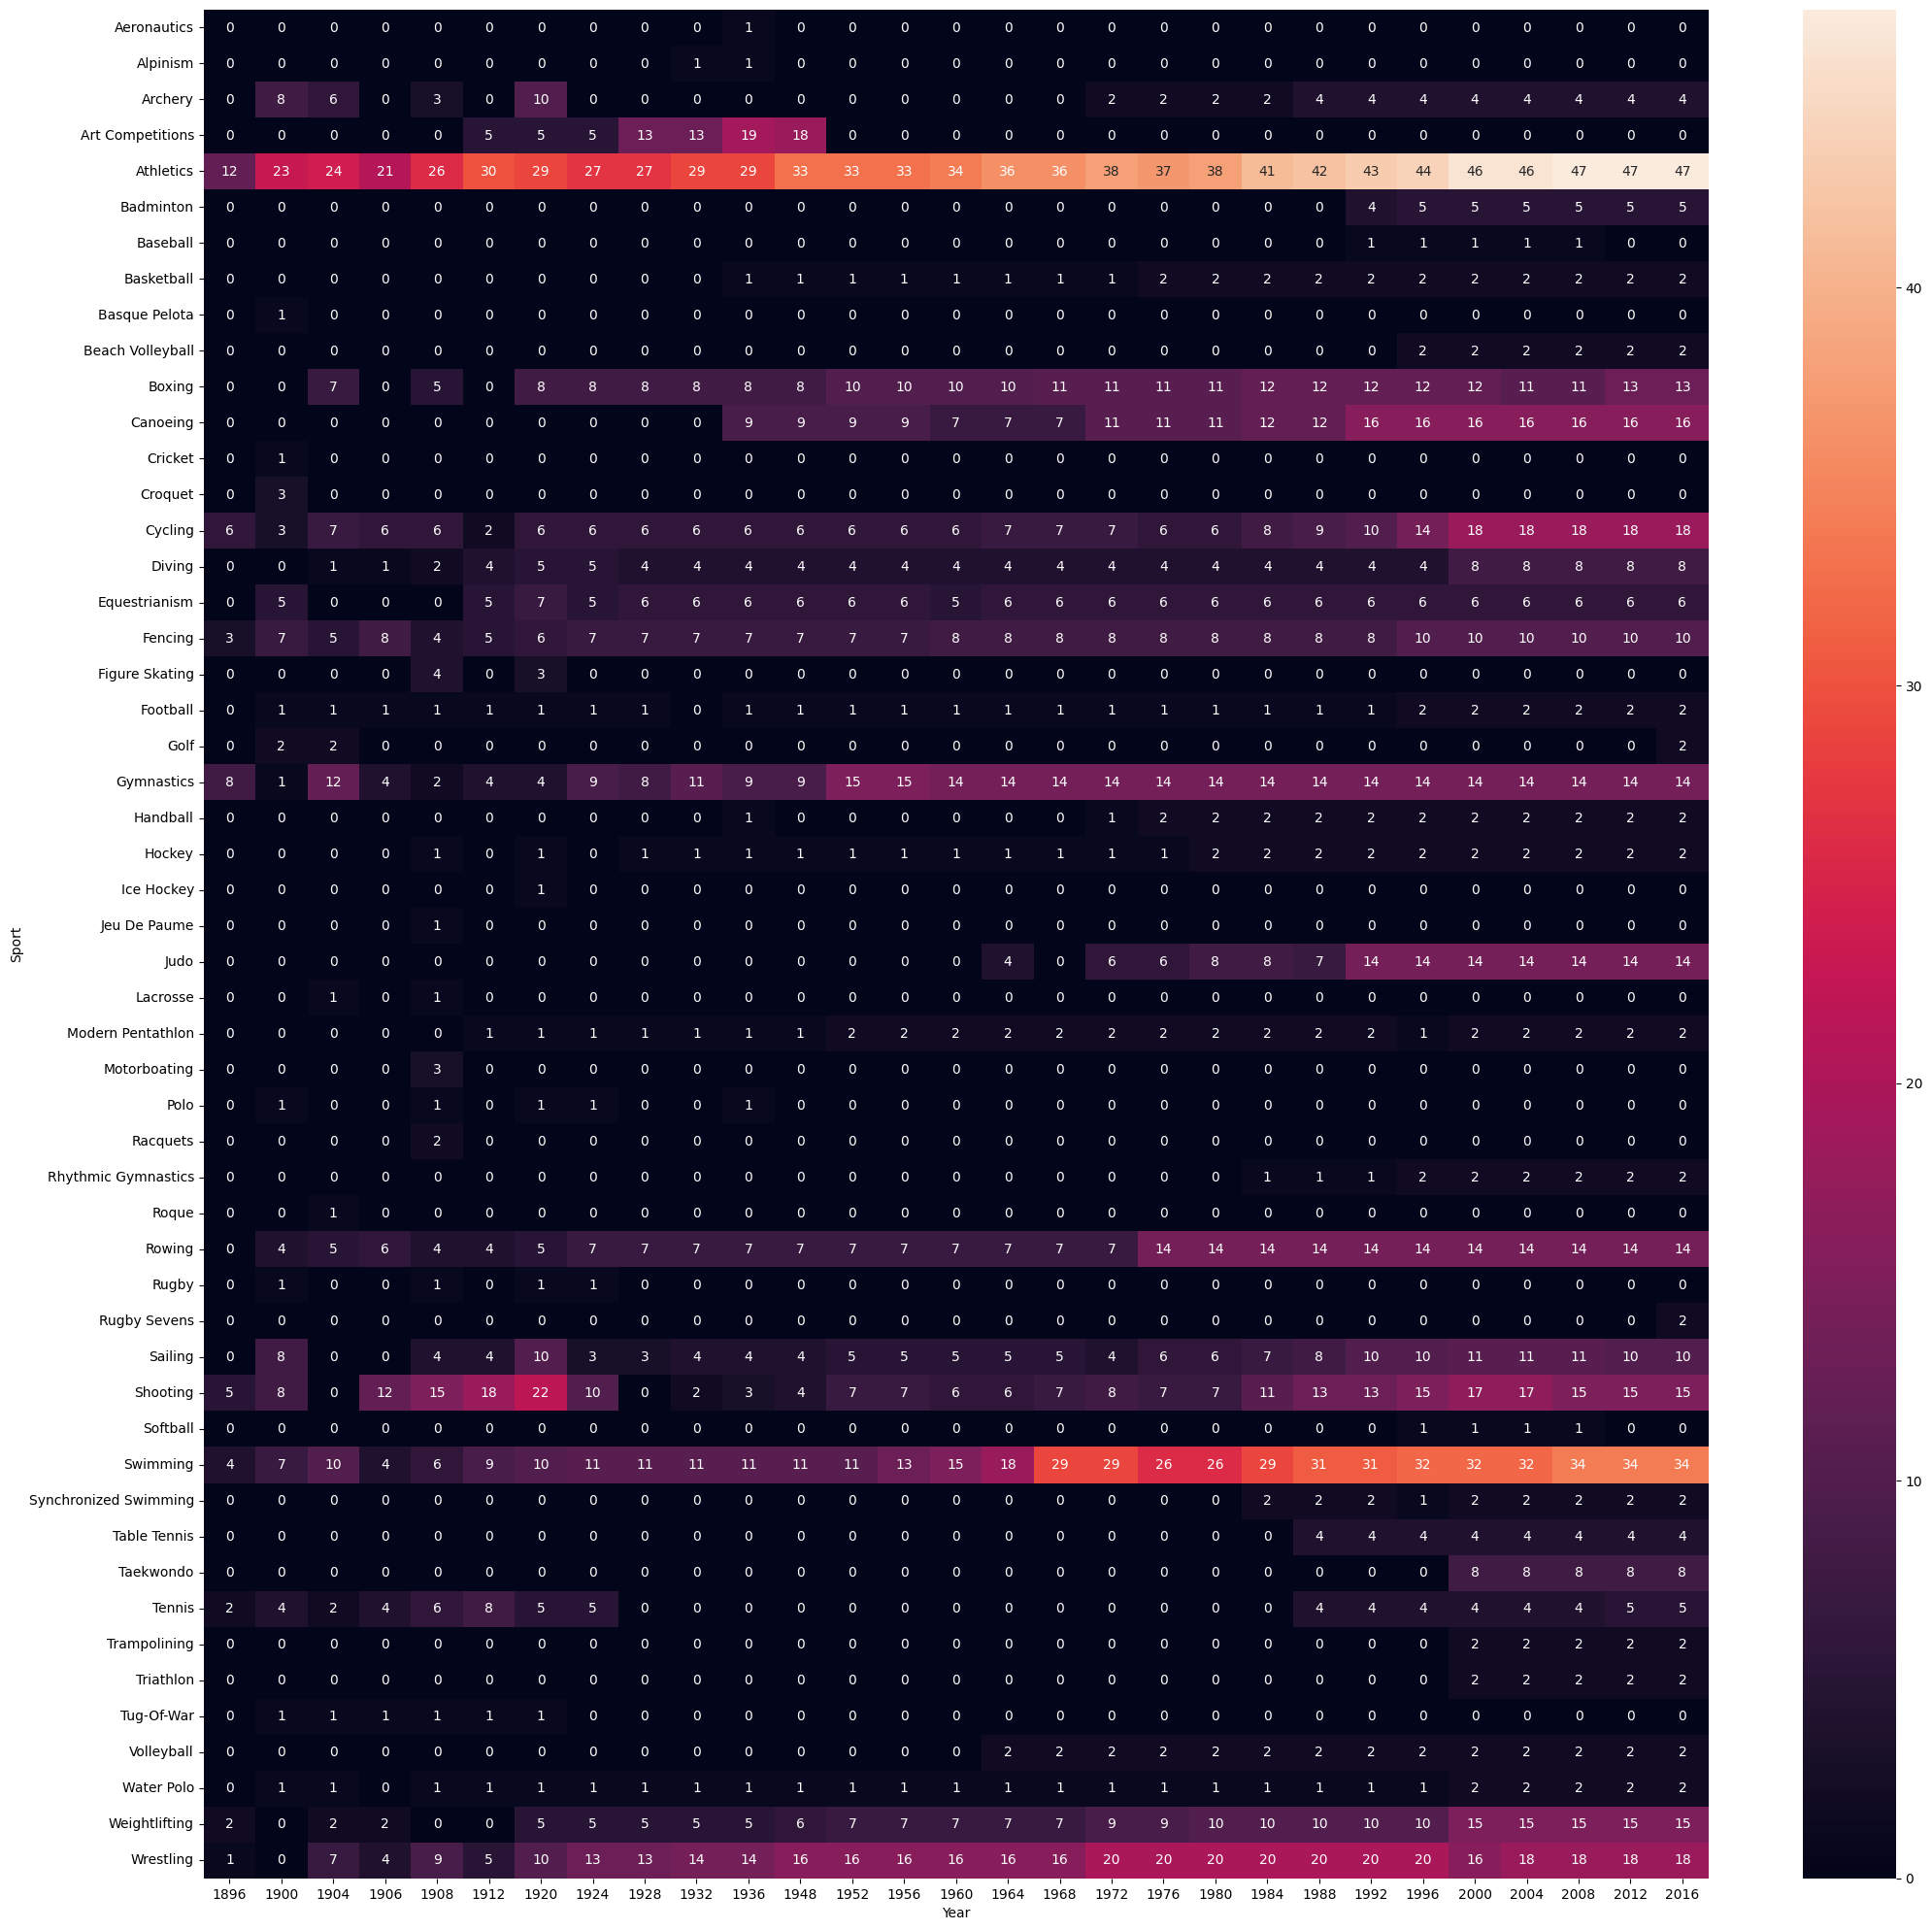

In [92]:
plt.figure(figsize=(25, 25))

sns.heatmap(x.pivot_table(index='Sport', columns='Year', values='Event', aggfunc='count').fillna(0).astype(int), annot=True)

### Most Decorated Athletes in olympics history

In [18]:
def most_successful(df, sport):
    temp_df = df.dropna(subset=['Medal'])

    if sport != 'overall':
        temp_df = temp_df[temp_df['Sport'] == sport]

    x = temp_df['Name'].value_counts().reset_index().head(15).merge(df, on='Name', how='left')[['Name', 'count', 'Sport', 'region']].drop_duplicates('Name')
    
    x.rename(columns={'count' : "Medals"}, inplace=True)

    return x 

In [69]:
most_successful(athlete, 'overall')

,Name,Medals,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
97,Takashi Ono,13,Gymnastics,Japan
130,Edoardo Mangiarotti,13,Fencing,Italy
144,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
157,Birgit Fischer-Schmidt,12,Canoeing,Germany
170,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
187,Ryan Steven Lochte,12,Swimming,USA


## 3. Country wise 

- Countrywise medal tally per year(line plot)
- What countries are good at heatmaps
- Most successful Athletes(Top 10)

### a. Countrywise medal tally per year(line plot)

In [19]:
temp_df = athlete.dropna(subset=['Medal'])

In [20]:
temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_5560\1975138824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace=True)


In [21]:
new_df = temp_df[temp_df['region'] == 'USA']
final_df = new_df.groupby(by='Year')['Medal'].count().reset_index()

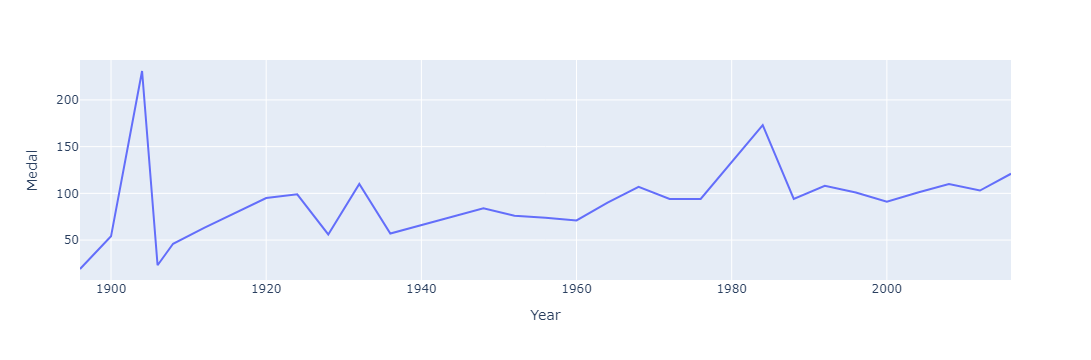

In [42]:
# plotting line graph

fig = px.line(final_df, x='Year', y='Medal')

fig.show()

### b. What countries are good at heatmaps

In [28]:
temp_df = athlete.dropna(subset=['Medal'])
temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_1868\1940724455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace=True)


In [29]:
new_df = temp_df[temp_df['region'] == 'China']
new_df.pivot_table(index = 'Sport', columns='Year', values='Medal', aggfunc='count').fillna(0).astype('int')

Year,1984,1988,1992,1996,2000,2004,2008,2012,2016
Sport,,,,,,,,,
Archery,1,0,1,1,0,1,3,2,0
Athletics,1,1,4,4,1,2,2,6,6
Badminton,0,0,4,4,8,5,8,8,3
Basketball,1,0,1,0,0,0,0,0,0
Beach Volleyball,0,0,0,0,0,0,2,0,0
Boxing,0,0,0,0,0,1,4,3,4
Canoeing,0,0,0,0,0,1,1,0,0
Cycling,0,0,0,0,1,1,1,4,1
Diving,3,6,5,5,10,9,11,10,10


<Axes: xlabel='Year', ylabel='Sport'>

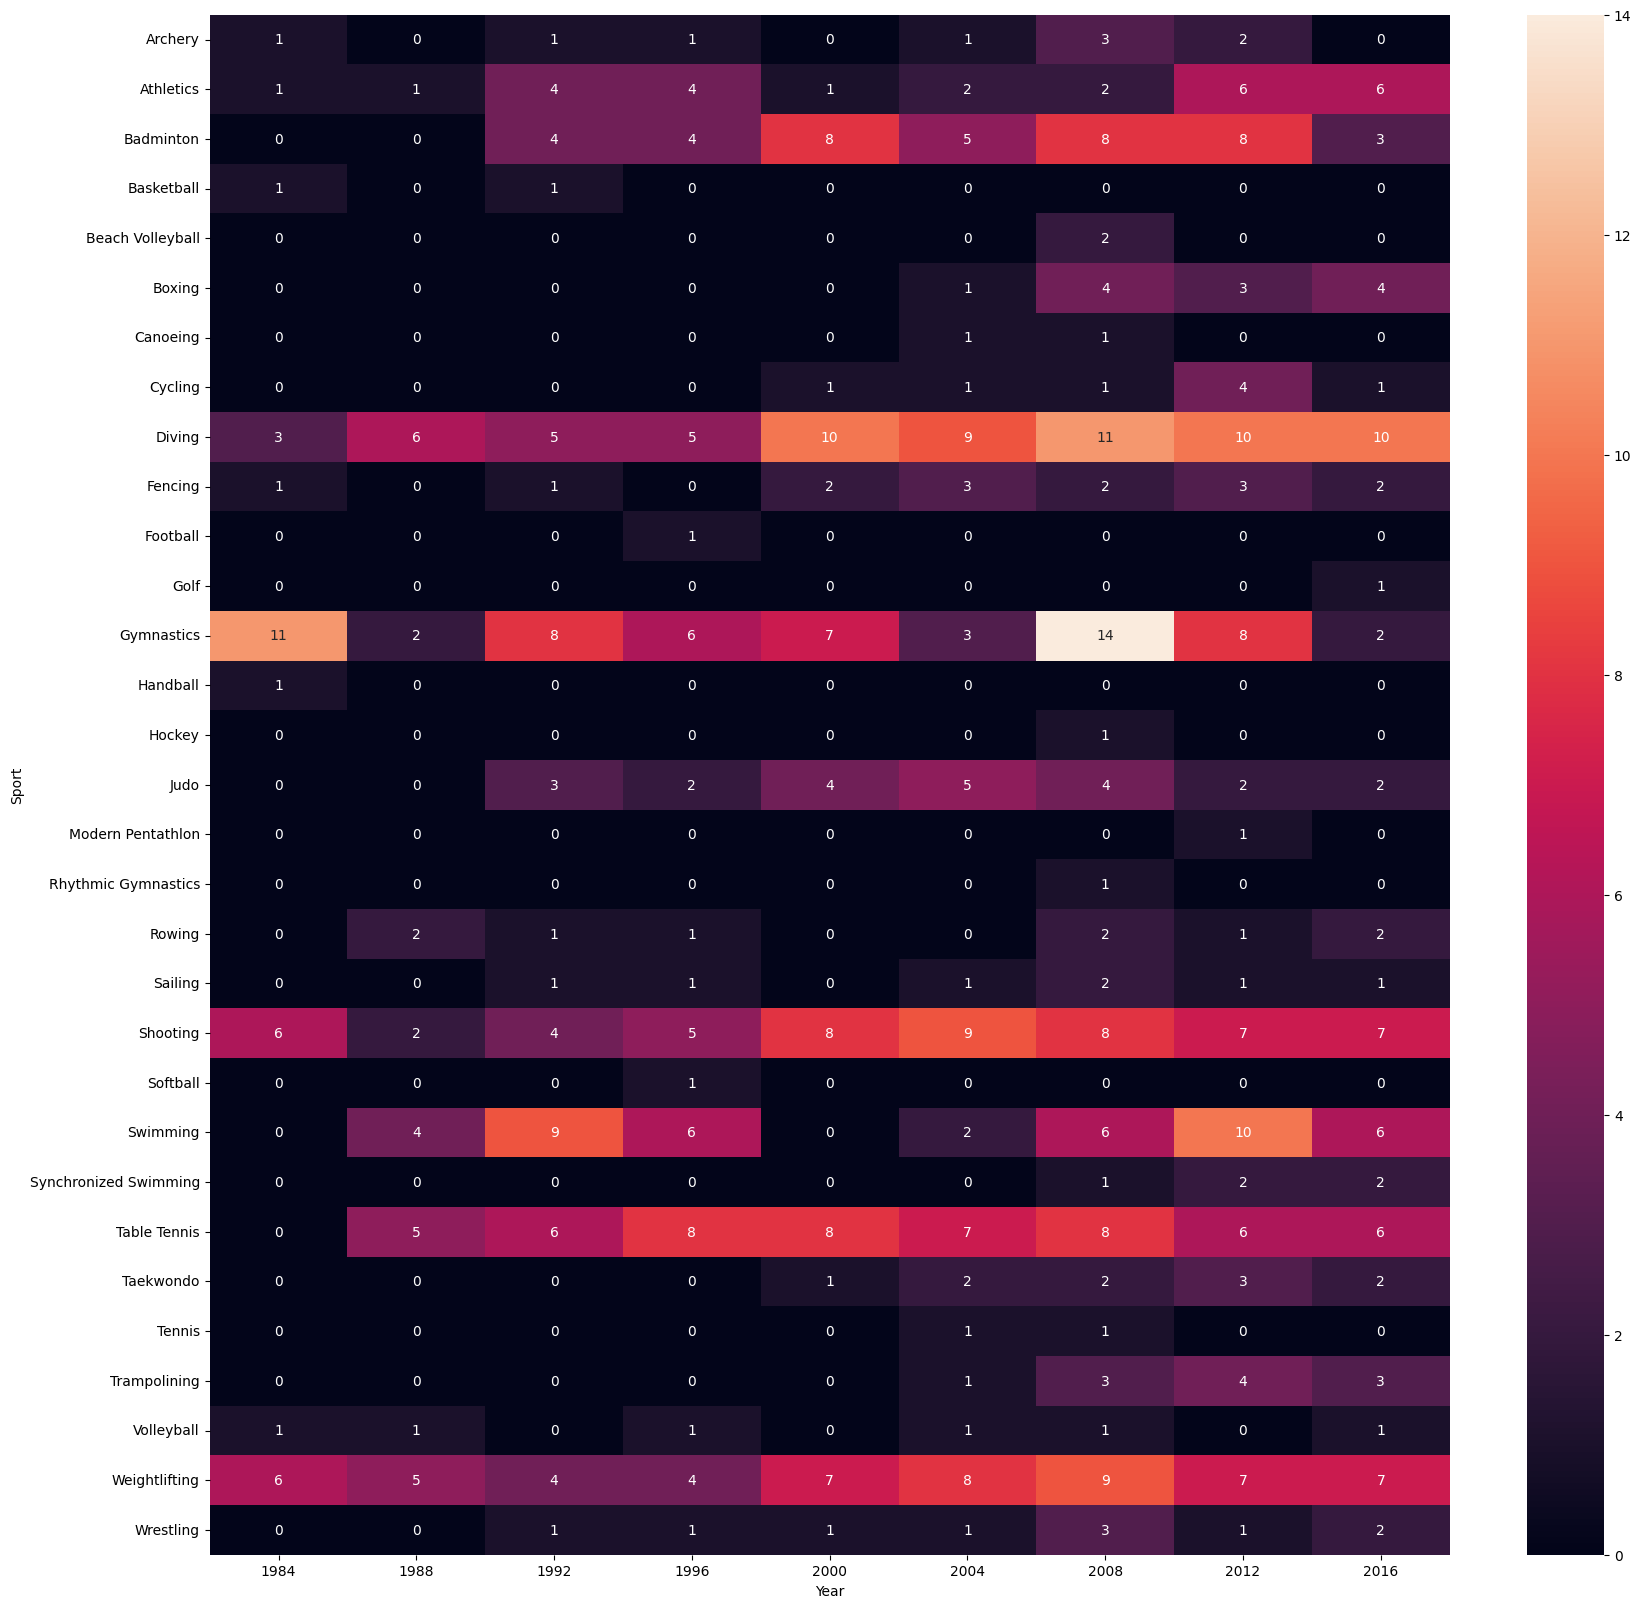

In [49]:
plt.figure(figsize=(20, 20))
sns.heatmap(new_df.pivot_table(index = 'Sport', columns='Year', values='Medal', aggfunc='count').fillna(0).astype('int'), annot=True)

### c. Most successful Athletes(Top 10)

In [29]:
def most_successful(df, country):
    temp_df = df.dropna(subset=['Medal'])

    
    temp_df = temp_df[temp_df['region'] == country]

    x = temp_df['Name'].value_counts().reset_index().head(15).merge(df, on='Name', how='left')[['Name', 'count', 'Sport']].drop_duplicates('Name')
    
    x.rename(columns={'count' : "Medals"}, inplace=True)

    return x 

In [31]:
most_successful(athlete, 'China')

,Name,Medals,Sport
0,Wu Minxia,7,Diving
7,Yang Wei,7,Badminton
33,Zou Kai,6,Gymnastics
41,Wang Yifu,6,Shooting
51,Li Xiaoshuang,6,Gymnastics
67,Li Ning,6,Gymnastics
83,Sun Yang,6,Swimming
93,Wang Hao,6,Table Tennis
104,Guo Jingjing,6,Diving
111,Chen Ruolin,5,Diving


## 4. Athlete wise 

In [23]:
import plotly.figure_factory as ff

In [24]:
athlete_df = athlete.drop_duplicates(subset=['Name', 'region'])

In [25]:
x1 = athlete_df['Age'].dropna()
x2 = athlete_df[athlete_df['Medal']=='Gold']['Age'].dropna()
x3 = athlete_df[athlete_df['Medal']=='Silver']['Age'].dropna()
x4 = athlete_df[athlete_df['Medal']=='Bronze']['Age'].dropna()

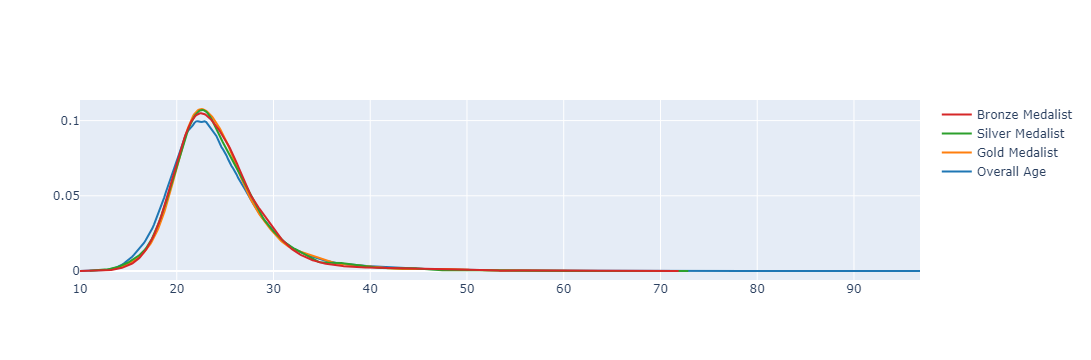

In [18]:
fig = ff.create_distplot([x1, x2, x3, x4], ['Overall Age', 'Gold Medalist', 'Silver Medalist', 'Bronze Medalist'], show_hist=False, show_rug=False )
fig.show()

### Most Decorated Players in famous Sports

In [30]:
famous_sports = ['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics', 'Swimming',
    'Badminton', 'Sailing', 'Gymnastics', 'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
    'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving',
    'Canoeing' , 'Tennis', 'Golf', 'Softball', 'Archery', 'Volleyball', 'Synchronized Swimming', 
    'Table Tennis', 'Baseball', 'Rhythmic Gymnastics', 'Rugby Sevens', 'Beach Volleyball',
    'Triathion', 'Rugby', 'Polo', 'Ice Hockey']

In [35]:
x = []
name = []
for sport in famous_sports:
        temp_df = athlete_df[athlete_df['Sport'] == sport]
        ages = temp_df[temp_df['Medal'] == 'Gold']['Age'].dropna()

        if not ages.empty:
            x.append(ages)
            name.append(sport)

In [36]:
fig = ff.create_distplot(x, name, show_hist=False, show_rug=False)

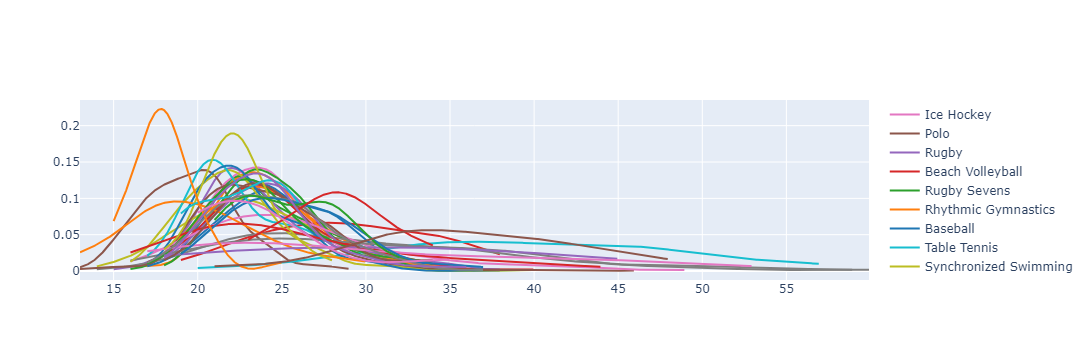

In [37]:
fig.show()

In [27]:
famous_sports

['Basketball',
 'Judo',
 'Football',
 'Tug-Of-War',
 'Athletics',
 'Swimming',
 'Badminton',
 'Sailing',
 'Gymnastics',
 'Art Competitions',
 'Handball',
 'Weightlifting',
 'Wrestling',
 'Water Polo',
 'Hockey',
 'Rowing',
 'Fencing',
 'Shooting',
 'Boxing',
 'Taekwondo',
 'Cycling',
 'Diving',
 'Canoeing',
 'Tennis',
 'Golf',
 'Softball',
 'Archery',
 'Volleyball',
 'Synchronized Swimming',
 'Table Tennis',
 'Baseball',
 'Rhythmic Gymnastics',
 'Rugby Sevens',
 'Beach Volleyball',
 'Triathion',
 'Rugby',
 'Polo',
 'Ice Hockey']

### c. Height, Weight, Medalist and Sex of Athletes

In [38]:
athlete_df['Medal'].fillna('No Medal', inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_5560\2256303489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  athlete_df['Medal'].fillna('No Medal', inplace=True)


<Axes: xlabel='Weight', ylabel='Height'>

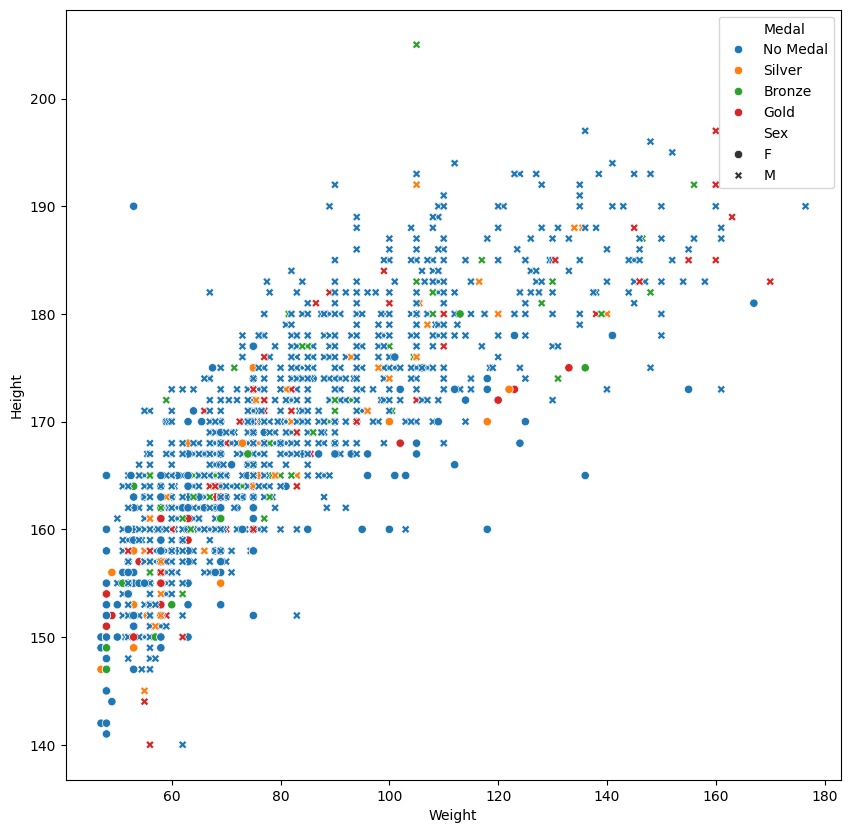

In [49]:
plt.figure(figsize=(10, 10))

temp_df = athlete_df[athlete_df['Sport'] == 'Weightlifting']

sns.scatterplot(x='Weight', y='Height', hue='Medal', style='Sex', data=temp_df)

### d. Distribution of Male vs Female in olympics over the years

In [54]:
men = athlete_df[athlete_df['Sex'] == "M"].groupby('Year').count()['Name'].reset_index()
women = athlete_df[athlete_df['Sex'] == "F"].groupby('Year').count()['Name'].reset_index()

In [59]:
final = men.merge(women, on='Year')
final.rename(columns={'Name_x' : "Male", "Name_y" : 'Female'}, inplace=True)

In [63]:
final.head()

,Year,Male,Female
0,1900,1181,23
1,1904,629,6
2,1906,759,6
3,1908,1772,44
4,1912,1978,53


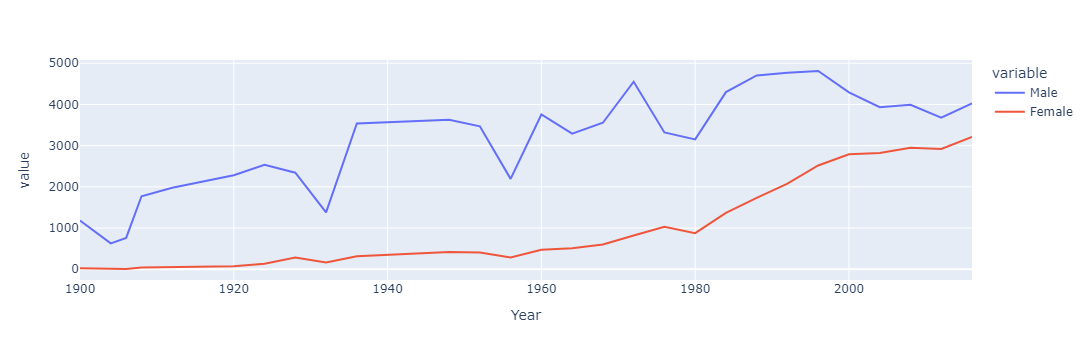

In [64]:
fig = px.line(final, x='Year', y=['Male', 'Female'])
fig.show()